# 주제 : 우리 애는 머리는 좋은데, 공부를 안해서 그래요 - 데이터로 살펴보는 우리 아이 학습 성공/ 실패 요소


### - 연구용 데이터 관련하여
    - 논문을 쓰기 위해 사용되기 때문에 데이터가 테이블 형식으로 잘 정리가 되어있음

### - 데이터 소개
    - 이번 주제는 xAPI-Edu-Data 데이터셋을 사용합니다.
    
    - 다음 1개의 csv 파일을 사용합니다.
    xAPI-Edu-Data.csv
    
    - 각 파일의 컬럼은 아래와 같습니다.
    gender: 학생의 성별 (M: 남성, F: 여성)
    NationaliTy: 학생의 국적
    PlaceofBirth: 학생이 태어난 국가
    StageID: 학생이 다니는 학교 (초,중,고)
    GradeID: 학생이 속한 성적 등급
    SectionID: 학생이 속한 반 이름
    Topic: 수강한 과목
    Semester: 수강한 학기 (1학기/2학기)
    Relation: 주 보호자와 학생의 관계
    raisedhands: 학생이 수업 중 손을 든 횟수
    VisITedResources: 학생이 과목 공지를 확인한 횟수
    Discussion: 학생이 토론 그룹에 참여한 횟수
    ParentAnsweringSurvey: 부모가 학교 설문에 참여했는지 여부
    ParentschoolSatisfaction: 부모가 학교에 만족했는지 여부
    StudentAbscenceDays: 학생의 결석 횟수 (7회 이상/미만)
    Class: 학생의 성적 등급 (L: 낮음, M: 보통, H: 높음)
        
    
    
- 데이터 출처: https://www.kaggle.com/aljarah/xAPI-Edu-Data



## Step 1. 데이터셋 준비하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


### 1-1 Kaggle API 세팅하기

In [2]:
import os
KAGGLE_USERNAME = pickle.load(open('./KAGGLE_USERNAME.plk','rb'))
KAGGLE_KEY = pickle.load(open('./KAGGLE_KEY.plk','rb'))

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']=KAGGLE_KEY



### 1-2 데이터 다운로드 및 압축 해제하기

In [12]:
!kaggle datasets download -d aljarah/xAPI-Edu-Data
!mkdir ./input_2/
!unzip *.zip -d ./input_2/ 
!rm *.zip

  0%|                                               | 0.00/5.54k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 5.54k/5.54k [00:00<00:00, 6.79MB/s]
mkdir: ./input_2/: File exists
Archive:  xAPI-Edu-Data.zip
  inflating: ./input_2/xAPI-Edu-Data.csv  


### 1-3. Pandas 라이브러리로 csv파일 읽어들이기

In [3]:
df = pd.read_csv("./input_2/xAPI-Edu-Data.csv")

In [4]:
!ls ./input_2/*

./input_2/xAPI-Edu-Data.csv


In [5]:
df.tail()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L
479,F,Jordan,Jordan,MiddleSchool,G-08,A,History,S,Father,35,14,23,62,No,Bad,Above-7,L


## Step 2. EDA 및 데이터 기초 통계 분석

### 2-1 데이터프레임의 각 컬럼 분석하기

In [6]:
df.head(n=5)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [8]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [9]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [10]:
df['gender'].value_counts()

M    305
F    175
Name: gender, dtype: int64

In [11]:
df['NationalITy'].value_counts()

KW             179
Jordan         172
Palestine       28
Iraq            22
lebanon         17
Tunis           12
SaudiArabia     11
Egypt            9
Syria            7
Lybia            6
USA              6
Iran             6
Morocco          4
venzuela         1
Name: NationalITy, dtype: int64

In [12]:
df['PlaceofBirth'].value_counts()

KuwaIT         180
Jordan         176
Iraq            22
lebanon         19
SaudiArabia     16
USA             16
Palestine       10
Egypt            9
Tunis            9
Lybia            6
Iran             6
Syria            6
Morocco          4
venzuela         1
Name: PlaceofBirth, dtype: int64

In [13]:
df['StageID'].value_counts()

MiddleSchool    248
lowerlevel      199
HighSchool       33
Name: StageID, dtype: int64

### 2-2 수치형 데이터의 히스토그램 그리기


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

<AxesSubplot:xlabel='raisedhands', ylabel='Count'>

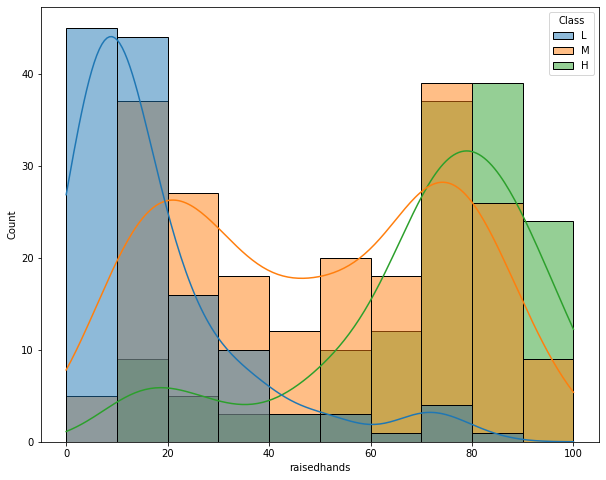

In [15]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x='raisedhands', hue='Class', hue_order=['L','M','H'], kde=True)

<AxesSubplot:xlabel='VisITedResources', ylabel='Count'>

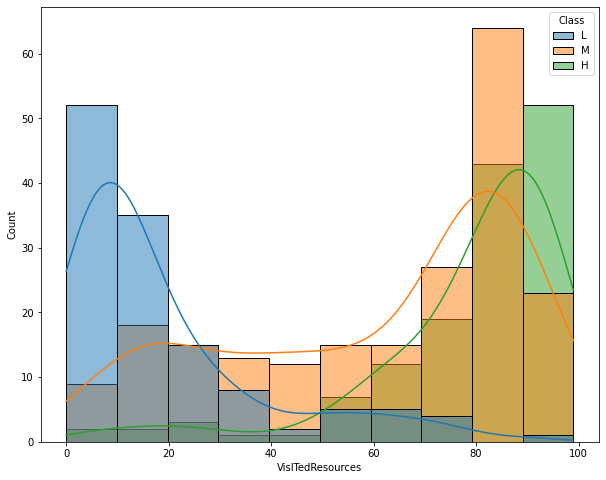

In [16]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x='VisITedResources', hue='Class', hue_order=['L', 'M', 'H'], kde=True)

<AxesSubplot:xlabel='AnnouncementsView', ylabel='Count'>

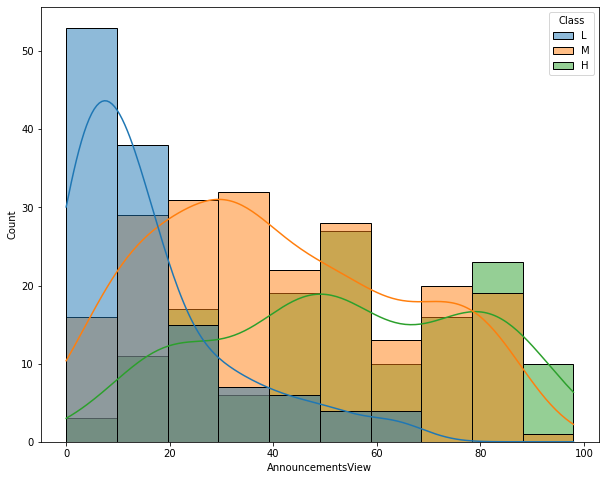

In [17]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x='AnnouncementsView', hue='Class', hue_order=['L', 'M', 'H'], kde=True)

<AxesSubplot:xlabel='Discussion', ylabel='Count'>

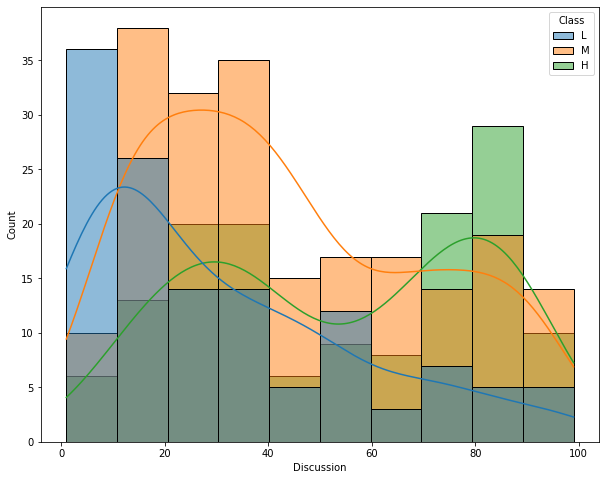

In [18]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x='Discussion', hue='Class', hue_order=['L', 'M', 'H'], kde=True)

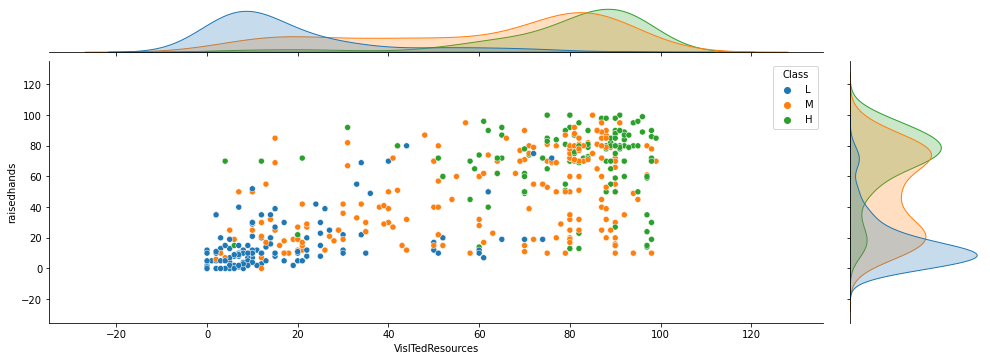

In [19]:
grid = sns.jointplot(x='VisITedResources', y='raisedhands',hue='Class',hue_order=['L', 'M','H'], data=df)
grid.fig.set_size_inches(15,5)

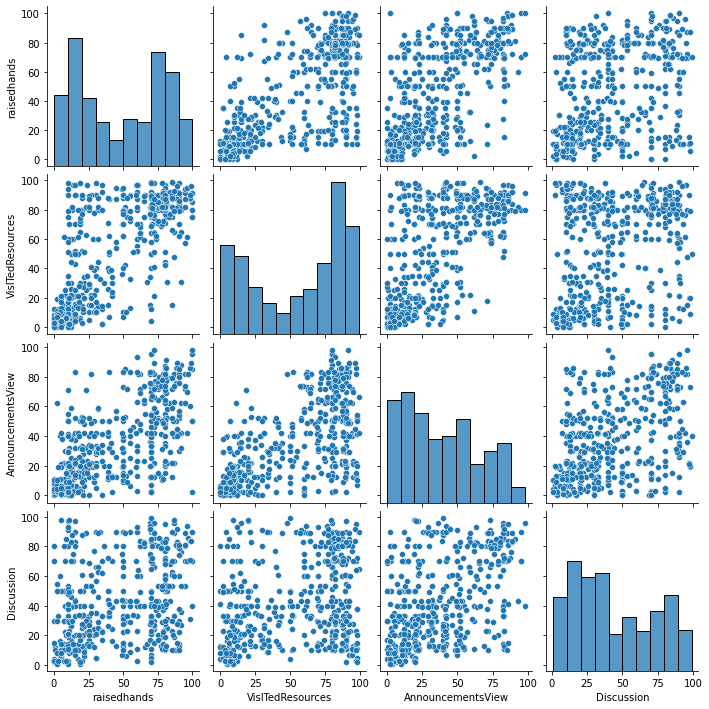

In [20]:
sns.pairplot(data=df)

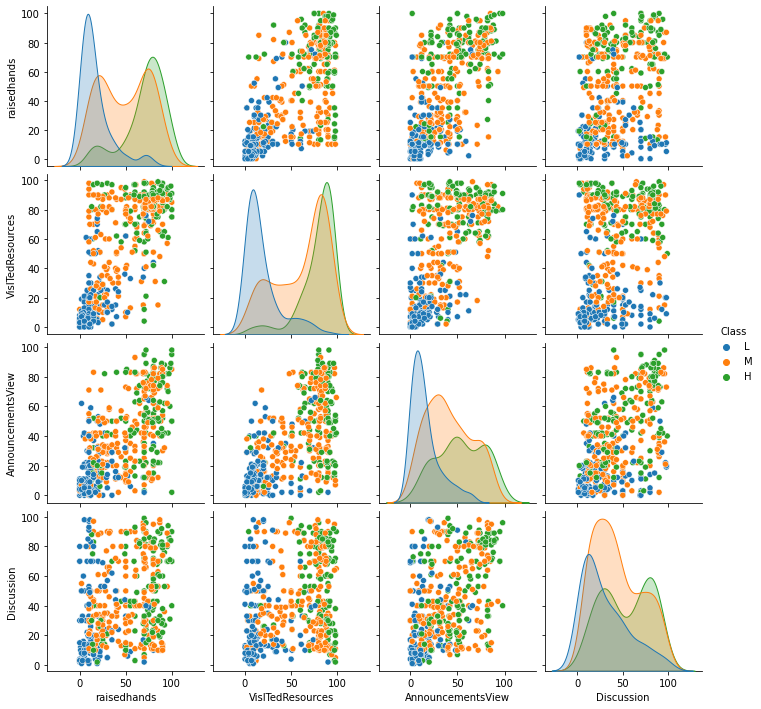

In [21]:
sns.pairplot(data=df, hue='Class', hue_order=['L','M','H'])

### 2-3 Countplot을 이용하여 범주별 통계 확인하기

<AxesSubplot:xlabel='Class', ylabel='count'>

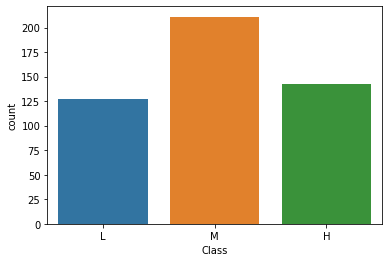

In [22]:
sns.countplot(x='Class', data=df, order=['L', 'M', 'H'])